# Filament Fragmentation Visualization

For each micrograph, plot every crYOLO filament chain (`rlnHelicalTubeID`)
in a different color, with:
- a small arrow at each chain's start/end showing the estimated tangent
  direction (same estimate `propose_filament_merges.py` uses)
- dashed orange lines connecting the closest loose-end pairs *between
  different chains*, labeled with distance in **raw coordinate units**
- a scale bar in the corner of each panel, so panel size can't be
  mistaken for absolute filament/gap size

**Known caveat (unresolved):** asyn and TMV are on different raw
coordinate scales. asyn micrographs span ~3700-3850 units with ~20
units between consecutive trace points; TMV micrographs span only
~250-1000 units with *exactly* 1.00 units between consecutive trace
points. That's not the same physical pixel scale — likely different
`box_distance`/binning/pixel-size between the two picking jobs. Distances
(and `max_dist` thresholds) are **not directly comparable across the two
datasets** until that's confirmed against ghez import-job metadata. Numbers
below are printed so this is never hidden by autoscaled axes.

In [6]:
%matplotlib inline
import glob
from itertools import combinations

import numpy as np
import matplotlib.pyplot as plt

from propose_filament_merges import read_star_filament_segmented, chain_endpoints_with_tangent

plt.rcParams["figure.dpi"] = 110

In [7]:
def get_loose_ends(chains, n_tangent=4):
    """One entry per chain-end: chain_id, end, point, tangent (or None)."""
    loose_ends = []
    for chain_id, points in chains.items():
        if len(points) < 2:
            continue
        start_pt, start_tan, end_pt, end_tan = chain_endpoints_with_tangent(
            points, n_tangent=n_tangent
        )
        loose_ends.append({"chain_id": chain_id, "end": "start", "point": start_pt, "tangent": start_tan})
        loose_ends.append({"chain_id": chain_id, "end": "end", "point": end_pt, "tangent": end_tan})
    return loose_ends


def closest_inter_chain_pairs(loose_ends, top=5):
    pairs = []
    for a, b in combinations(loose_ends, 2):
        if a["chain_id"] == b["chain_id"]:
            continue
        dist = np.linalg.norm(a["point"] - b["point"])
        pairs.append((dist, a, b))
    pairs.sort(key=lambda p: p[0])
    return pairs[:top]


def coordinate_stats(chains):
    """x/y range + median inter-point step, to surface scale differences
    that autoscaled axes would otherwise hide."""
    all_pts = np.array([p for pts in chains.values() for p in pts])
    x_range = all_pts[:, 0].max() - all_pts[:, 0].min()
    y_range = all_pts[:, 1].max() - all_pts[:, 1].min()
    steps = []
    for pts in chains.values():
        pts = np.array(pts)
        if len(pts) > 1:
            steps.extend(np.linalg.norm(np.diff(pts, axis=0), axis=1).tolist())
    median_step = float(np.median(steps)) if steps else float("nan")
    return x_range, y_range, median_step

In [8]:
def add_scale_bar(ax, bar_len, label=None):
    """Fixed-length scale bar in data units, anchored to the bottom-left
    of the axes, so panel size never gets mistaken for absolute scale."""
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
    x0 = xlim[0] + 0.05 * (xlim[1] - xlim[0])
    y0 = ylim[0] - 0.06 * (ylim[1] - ylim[0])  # ylim is inverted (image coords)
    ax.plot([x0, x0 + bar_len], [y0, y0], color="black", linewidth=2.5,
            clip_on=False, solid_capstyle="butt")
    ax.annotate(label or f"{bar_len:.0f} units", (x0 + bar_len / 2, y0),
                xytext=(0, -4), textcoords="offset points",
                ha="center", va="top", fontsize=6.5, clip_on=False)


def plot_micrograph(ax, star_path, highlight_top=5, tangent_frac=0.02, scale_bar_len=None):
    chains = read_star_filament_segmented(star_path)
    loose_ends = get_loose_ends(chains)
    x_range, y_range, median_step = coordinate_stats(chains)

    cmap = plt.get_cmap("tab20")
    for i, (chain_id, points) in enumerate(chains.items()):
        pts = np.array(points, dtype=float)
        color = cmap(i % 20)
        ax.plot(pts[:, 0], pts[:, 1], "-", color=color, linewidth=1.2, alpha=0.9)
        ax.scatter(pts[:, 0], pts[:, 1], s=6, color=color, zorder=3)
        mid = pts[len(pts) // 2]
        ax.annotate(str(chain_id), mid, fontsize=6, color=color,
                    xytext=(3, 3), textcoords="offset points")

    # tangent arrows, scaled to a fraction of this panel's own data range
    # (a fixed pixel length would be invisible on asyn's ~3800-unit range
    # and comically large on TMV's ~600-unit range)
    tangent_len = tangent_frac * max(x_range, y_range)
    for le in loose_ends:
        if le["tangent"] is None:
            continue
        x, y = le["point"]
        dx, dy = le["tangent"] * tangent_len
        ax.arrow(x, y, dx, dy, head_width=tangent_len * 0.35, head_length=tangent_len * 0.45,
                  fc="black", ec="black", alpha=0.6, length_includes_head=True, zorder=4)

    # closest inter-chain gaps, dashed + labeled (raw units -- see caveat above)
    closest = closest_inter_chain_pairs(loose_ends, top=highlight_top)
    for dist, a, b in closest:
        xa, ya = a["point"]
        xb, yb = b["point"]
        ax.plot([xa, xb], [ya, yb], "--", color="orange", linewidth=1.3, zorder=5)
        mx, my = (xa + xb) / 2, (ya + yb) / 2
        ax.annotate(f"{dist:.0f}", (mx, my), fontsize=6.5, color="darkorange",
                    fontweight="bold", ha="center")

    fname = star_path.split(chr(92))[-1]
    ax.set_title(
        f"{fname}\n{len(chains)} chains | range {x_range:.0f}x{y_range:.0f} | median step {median_step:.2f}",
        fontsize=7.5,
    )
    ax.set_aspect("equal")
    ax.invert_yaxis()  # image coordinates: origin top-left, y increases downward
    ax.tick_params(labelsize=6)

    if scale_bar_len is None:
        scale_bar_len = max(x_range, y_range) * 0.2
    add_scale_bar(ax, scale_bar_len)


def plot_dataset(files, suptitle):
    n = len(files)
    ncols = 2
    nrows = (n + 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(13, 6.5 * nrows))
    axes = np.array(axes).reshape(-1)

    # shared scale bar length across the whole dataset, so bar length
    # means the same thing in every panel of this figure
    ranges = []
    for path in files:
        chains = read_star_filament_segmented(path)
        x_range, y_range, _ = coordinate_stats(chains)
        ranges.append(max(x_range, y_range))
    shared_scale_bar = round(np.median(ranges) * 0.2, -1) or 1

    for ax, path in zip(axes, files):
        plot_micrograph(ax, path, scale_bar_len=shared_scale_bar)
    for ax in axes[len(files):]:
        ax.axis("off")
    fig.suptitle(suptitle, fontsize=13)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

## Raw coordinate scale per file

Printed explicitly since autoscaled subplot axes hide this — see caveat above.

In [9]:
print(f"{'file':>65} {'x_range':>9} {'y_range':>9} {'median_step':>12}")
for path in sorted(glob.glob("asyn/*.star")) + sorted(glob.glob("TMV/*.star")):
    chains = read_star_filament_segmented(path)
    x_range, y_range, median_step = coordinate_stats(chains)
    print(f"{path:>65} {x_range:9.1f} {y_range:9.1f} {median_step:12.2f}")

                                                             file   x_range   y_range  median_step
 asyn\FoilHole_19863007_Data_19857040_23_20250220_131032_EER.star    3765.8    3827.8        20.14
 asyn\FoilHole_19863037_Data_19857040_32_20250220_125351_EER.star    3700.9    3847.2        20.20
 asyn\FoilHole_19863050_Data_19857030_58_20250220_131612_EER.star    3822.8    3768.8        20.41
 asyn\FoilHole_19863153_Data_19857092_41_20250220_132420_EER.star    3825.8    3828.9        20.12
                     TMV\KMCB2_D8_RL_TMV_0.05mgmL_9300X_0007.star     254.5     456.8         1.00
                     TMV\KMCB2_D8_RL_TMV_0.05mgmL_9300X_0021.star     977.8     879.1         1.00
                     TMV\KMCB2_D8_RL_TMV_0.05mgmL_9300X_0060.star     690.2     800.3         1.00
                     TMV\KMCB2_D8_RL_TMV_0.05mgmL_9300X_0071.star     584.5     539.9         1.00


## asyn dataset

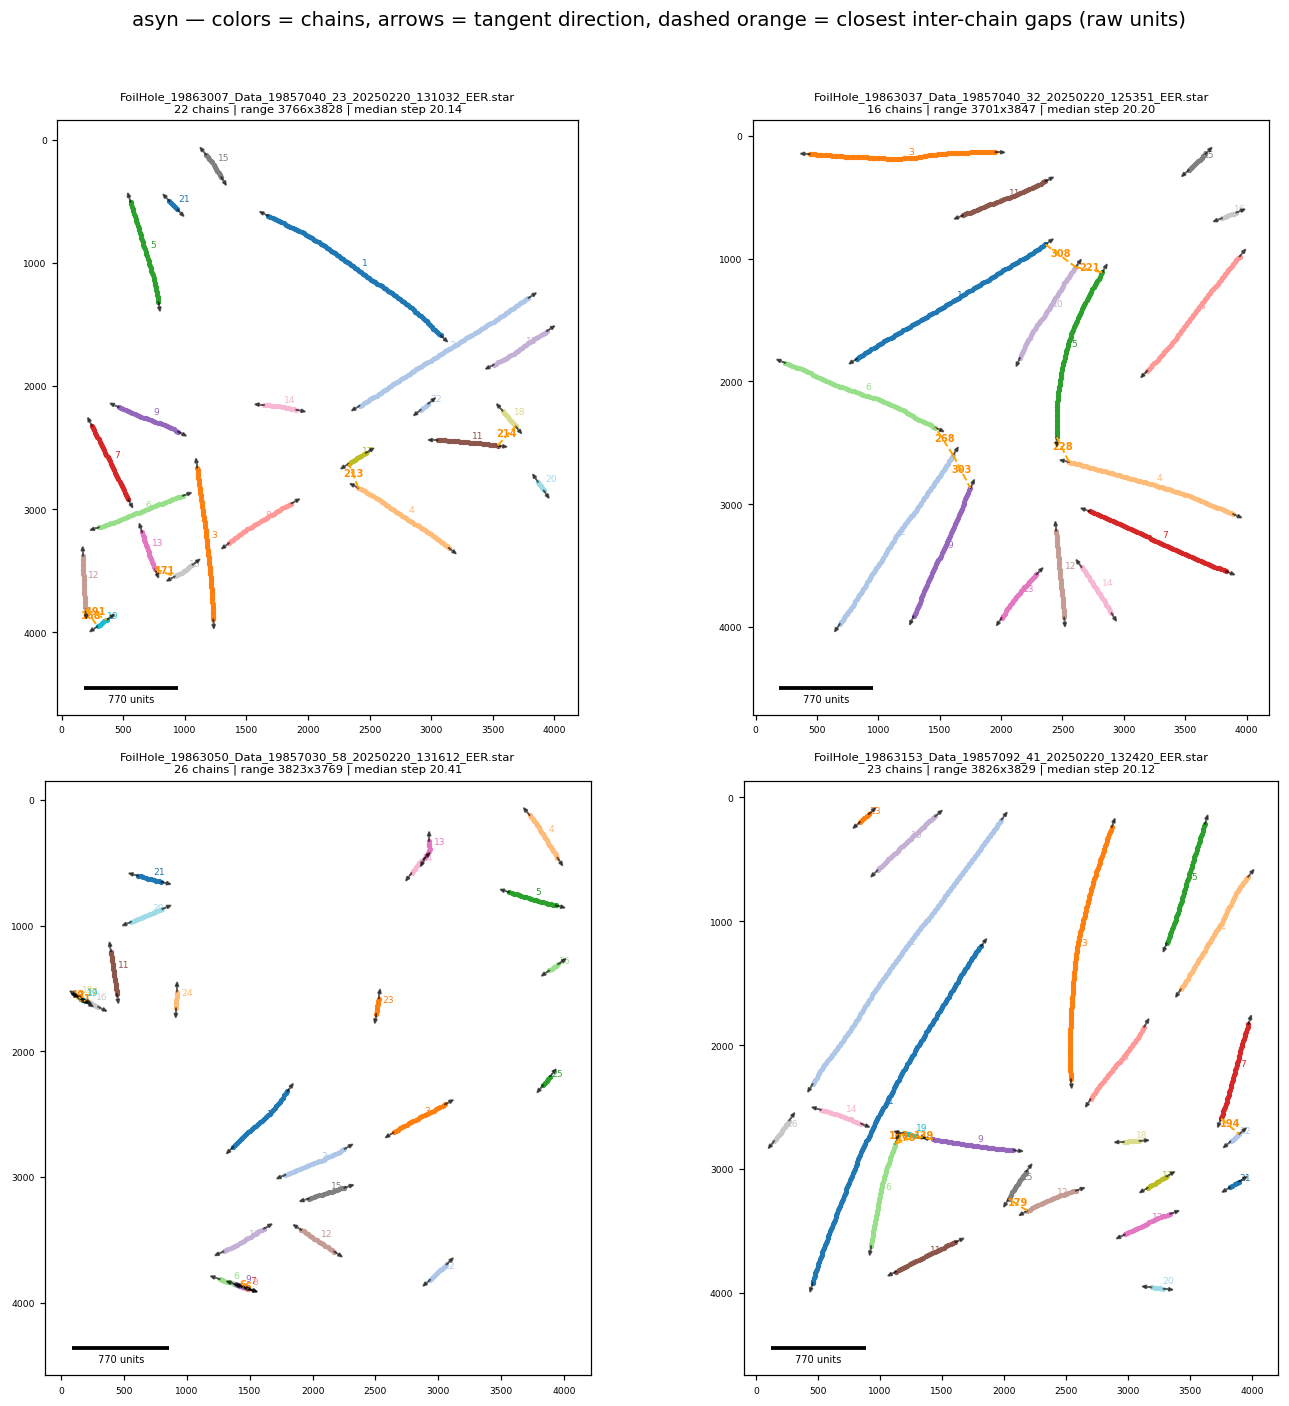

In [10]:
asyn_files = sorted(glob.glob("asyn/*.star"))
plot_dataset(asyn_files, "asyn — colors = chains, arrows = tangent direction, dashed orange = closest inter-chain gaps (raw units)")

## TMV dataset

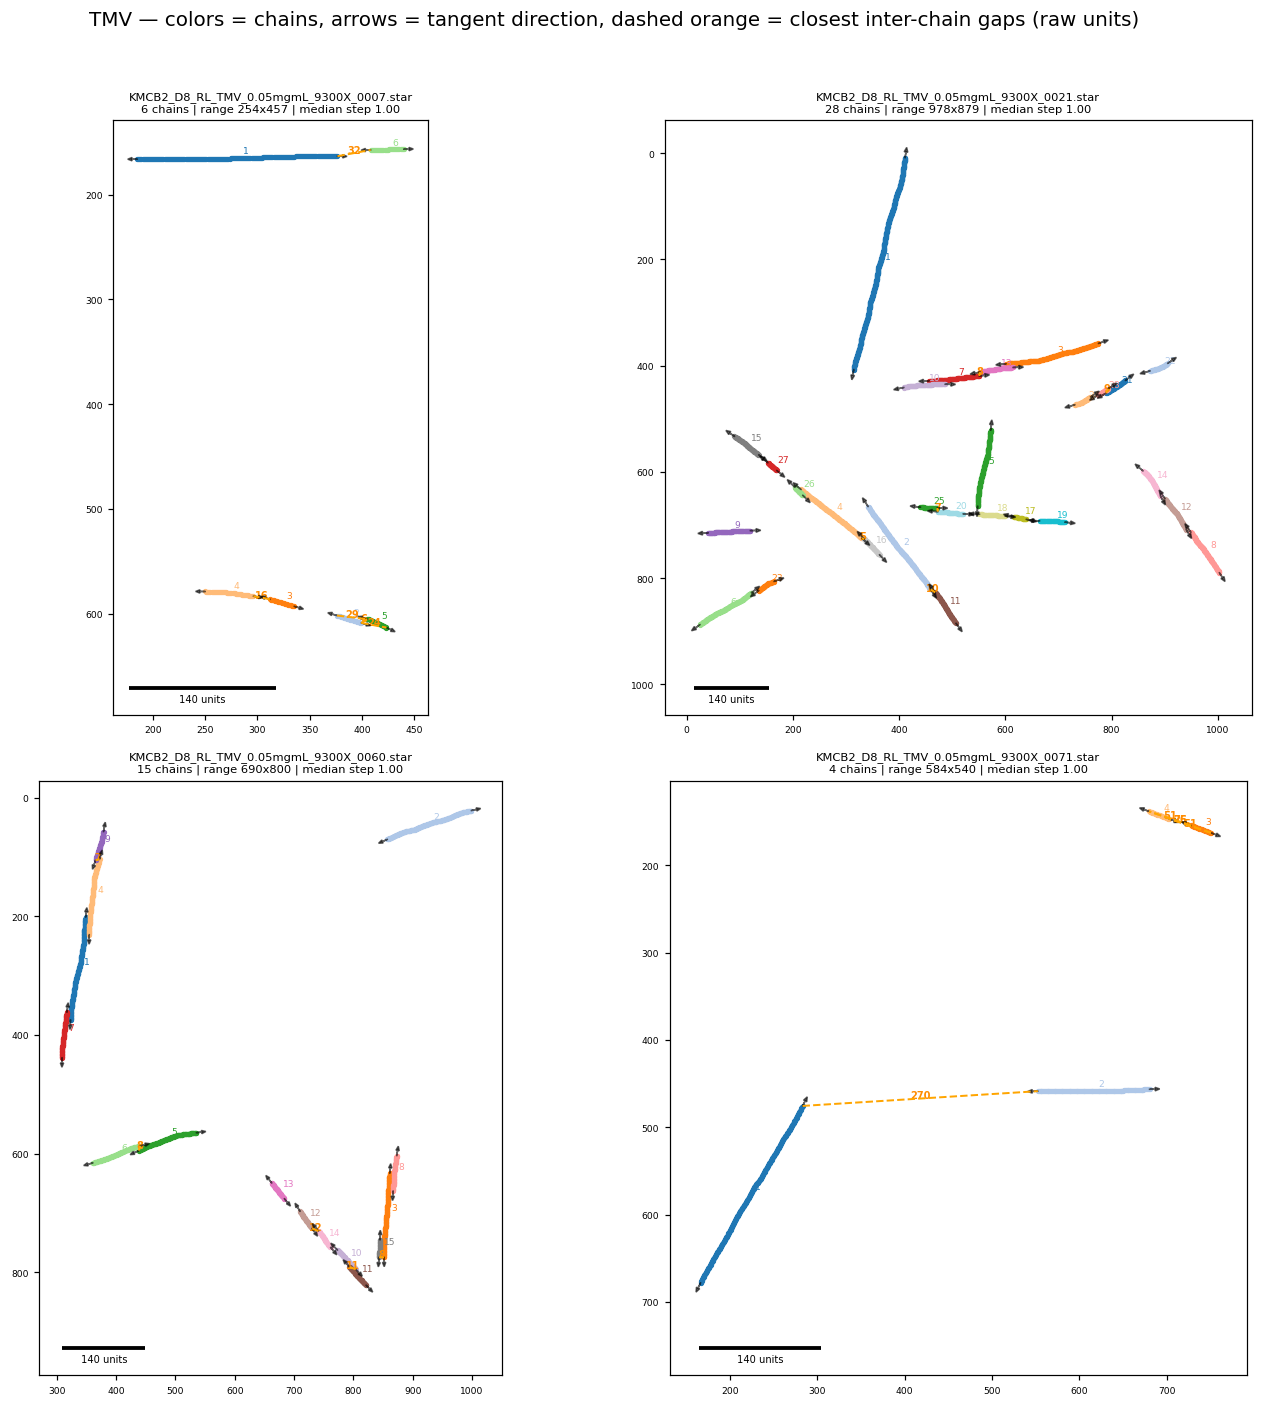

In [11]:
tmv_files = sorted(glob.glob("TMV/*.star"))
plot_dataset(tmv_files, "TMV — colors = chains, arrows = tangent direction, dashed orange = closest inter-chain gaps (raw units)")

## How to read these plots

- **Same-colored connected line** = one crYOLO chain (`rlnHelicalTubeID`).
- **Black arrows** = estimated tangent direction at each chain's loose end
  (points away from the chain body — same convention as
  `propose_filament_merges.py`), scaled to each panel's own data range so
  they stay visible at any zoom level.
- **Dashed orange lines** = the closest loose-end gaps between *different*
  chains, labeled with distance in raw coordinate units.
- **Scale bar** (bottom-left of each panel) = a fixed length in raw units,
  shared across all panels *within* one dataset's figure — use it to judge
  true relative size instead of the panel's rendered size, since panels
  autoscale to fit their own data.

A dashed line is a plausible **real fragmentation break** if:
- the two arrows point roughly toward each other (antiparallel), and
- the chains on either side look colinear / continue each other's path.

A dashed line is more likely a **false positive** (two separate filaments
passing near each other, not a break) if:
- the arrows point in unrelated directions, or
- the two chains clearly have different orientation/curvature.

Remember the scale caveat at the top: don't compare a raw-unit distance in
a TMV panel to one in an asyn panel — they aren't the same physical scale
until pixel size/binning is confirmed.